### **[Regularization Frameworks: Taming Financial Market Noise](https://medium.com/@simplifiedzone/5effbc951e44)**

> *Machine Learning for Quants*

```
"""
Title: Regularized Time-Series Momentum Trading Engine
Author: Swetank M.
Description: Generates multi-collinear financial features, implements chronological TimeSeriesSplit cross-validation, tunes ElasticNet hyperparameters, and programmatically validates feature selection.
"""
```

In [1]:
import sys

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 8

%autosave 20

Autosaving every 20 seconds


In [2]:
# ---------------------------------------------------------
# Step 1: Deep Feature Engineering & Multicollinearity Injection
# ---------------------------------------------------------
print("Downloading historical data...")
df = yf.download('SPY', start='2012-01-01', end='2026-01-01', progress=False)

# Flatten MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
  df.columns = df.columns.get_level_values(0)

df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

# Generate Lags 1 to 10 (highly correlated time-series features)
lags = 10
feature_cols = []
for i in range(1, lags + 1):
  col_name = f'Lag_{i}'
  df[col_name] = df['Return'].shift(i)
  feature_cols.append(col_name)

# Inject rolling moving averages of returns to compound multicollinearity
df['SMA_3'] = df['Return'].rolling(window=3).mean()
df['SMA_5'] = df['Return'].rolling(window=5).mean()
df['SMA_10'] = df['Return'].rolling(window=10).mean()

# Inject rolling historical volatility features
df['Vol_5'] = df['Return'].rolling(window=5).std()
df['Vol_10'] = df['Return'].rolling(window=10).std()

# Inject 5 pure random white noise features (the model must learn to ignore these)
np.random.seed(42)
for i in range(1, 6):
  df[f'Noise_{i}'] = np.random.normal(0, 0.01, size=len(df))

feature_cols.extend(['SMA_3', 'SMA_5', 'SMA_10', 'Vol_5', 'Vol_10',
                    'Noise_1', 'Noise_2', 'Noise_3', 'Noise_4', 'Noise_5'])

df.dropna(inplace=True)

display(df.head(15))

X = df[feature_cols]
y = df['Return']

print(f"Feature Space created: {X.shape[1]} total features.")

Price,Close,High,Low,Open,Volume,Return,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10,SMA_3,SMA_5,SMA_10,Vol_5,Vol_10,Noise_1,Noise_2,Noise_3,Noise_4,Noise_5
Date,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-19,102.397,102.482,101.883,102.210,126328900,0.005,0.011,0.004,-0.005,0.002,0.001,0.009,0.002,-0.003,0.003,0.002,0.007,0.003,0.003,0.006,0.005,-0.005,-0.011,-0.013,0.007,0.014
2012-01-20,102.778,102.778,101.976,102.225,138230200,0.004,0.005,0.011,0.004,-0.005,0.002,0.001,0.009,0.002,-0.003,0.003,0.007,0.004,0.003,0.006,0.005,-0.005,0.015,-0.012,-0.005,-0.013
2012-01-23,102.514,103.012,102.023,102.436,129295800,-0.003,0.004,0.005,0.011,0.004,-0.005,0.002,0.001,0.009,0.002,-0.003,0.002,0.004,0.003,0.005,0.005,0.002,0.019,0.010,0.016,-0.007
2012-01-24,102.397,102.428,101.727,101.883,103083300,-0.001,-0.003,0.004,0.005,0.011,0.004,-0.005,0.002,0.001,0.009,0.002,0.000,0.003,0.003,0.005,0.005,-0.019,-0.001,0.004,-0.018,-0.006
2012-01-25,103.254,103.495,101.844,102.241,198613200,0.008,-0.001,-0.003,0.004,0.005,0.011,0.004,-0.005,0.002,0.001,0.009,0.002,0.003,0.003,0.005,0.005,-0.017,-0.012,0.011,-0.005,-0.000
2012-01-26,102.724,103.908,102.319,103.713,184880500,-0.005,0.008,-0.001,-0.003,0.004,0.005,0.011,0.004,-0.005,0.002,0.001,0.001,0.001,0.002,0.005,0.006,-0.006,0.021,0.003,-0.012,-0.003
2012-01-27,102.677,102.856,102.155,102.225,135259100,-0.000,-0.005,0.008,-0.001,-0.003,0.004,0.005,0.011,0.004,-0.005,0.002,0.001,-0.000,0.002,0.005,0.006,-0.010,0.016,0.001,0.004,-0.015
2012-01-30,102.327,102.381,101.306,101.657,147311800,-0.003,-0.000,-0.005,0.008,-0.001,-0.003,0.004,0.005,0.011,0.004,-0.005,-0.003,-0.000,0.002,0.005,0.005,0.003,0.007,-0.017,-0.011,-0.004
2012-01-31,102.288,102.958,101.789,102.833,157212000,-0.000,-0.003,-0.000,-0.005,0.008,-0.001,-0.003,0.004,0.005,0.011,0.004,-0.001,-0.000,0.002,0.005,0.005,-0.009,-0.008,-0.003,0.004,-0.001


Feature Space created: 20 total features.


In [3]:
# ---------------------------------------------------------
# Step 2: Chronological Train-Test Partitioning & Scaling
# ---------------------------------------------------------
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Regularization is highly sensitive to the scale of features.
# We fit the scaler strictly on training data to prevent look-ahead leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for clean column mapping
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

In [4]:
# ---------------------------------------------------------
# Step 3: Unconstrained Baseline OLS Model
# ---------------------------------------------------------
ols_model = LinearRegression()
ols_model.fit(X_train_scaled_df, y_train)
y_pred_ols = ols_model.predict(X_test_scaled_df)
ols_test_mse = mean_squared_error(y_test, y_pred_ols)

print(f"\nBaseline OLS Test Mean Squared Error: {ols_test_mse:.8f}")


Baseline OLS Test Mean Squared Error: 0.00000000


In [5]:
# ---------------------------------------------------------
# Step 4: Hyperparameter Optimization via TimeSeriesSplit
# ---------------------------------------------------------
print("\nInitializing TimeSeriesSplit Hyperparameter Grid Search...")

# 5 expanding window chronological splits
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the ElasticNet estimator
elastic = ElasticNet(max_iter=10000, random_state=42)

# Define search grid
# alpha: regularization strength
# l1_ratio: mix of L1 (Lasso) vs L2 (Ridge)
param_grid = {
  'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0],
  'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Setup GridSearchCV
# Note: scikit-learn uses negative MSE because it operates as a utility-maximizer.
grid_search = GridSearchCV(
  estimator=elastic,
  param_grid=param_grid,
  cv=tscv,
  scoring='neg_mean_squared_error',
  n_jobs=-1,
  verbose=1
)
grid_search.fit(X_train_scaled_df, y_train)

best_params = grid_search.best_params_
print(f"Optimal Parameters Located: {best_params}")

# Train the final model with best parameters
best_elastic = grid_search.best_estimator_
y_pred_elastic = best_elastic.predict(X_test_scaled_df)
elastic_test_mse = mean_squared_error(y_test, y_pred_elastic)

print(f"Optimized ElasticNet Test Mean Squared Error: {elastic_test_mse:.8f}")


Initializing TimeSeriesSplit Hyperparameter Grid Search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Optimal Parameters Located: {'alpha': 1e-05, 'l1_ratio': 0.1}
Optimized ElasticNet Test Mean Squared Error: 0.00000000



--- Programmatic Coefficient Comparison ---
Feature  OLS_Weight  ElasticNet_Weight
  Lag_1      -0.011             -0.011
  Lag_2      -0.011             -0.011
  Lag_3      -0.004             -0.000
  Lag_4      -0.004             -0.000
  Lag_5      -0.001             -0.000
  Lag_6      -0.001             -0.000
  Lag_7      -0.001              0.000
  Lag_8      -0.001             -0.000
  Lag_9      -0.001              0.000
 Lag_10      -0.000             -0.000
  SMA_3       0.012              0.017
  SMA_5       0.006              0.000
 SMA_10       0.003              0.000
  Vol_5       0.000              0.000
 Vol_10      -0.000              0.000
Noise_1      -0.000              0.000
Noise_2      -0.000              0.000
Noise_3      -0.000             -0.000
Noise_4      -0.000             -0.000
Noise_5       0.000              0.000

OLS retained 20 / 20 features.
Optimized ElasticNet driven to select 7 / 20 active features.


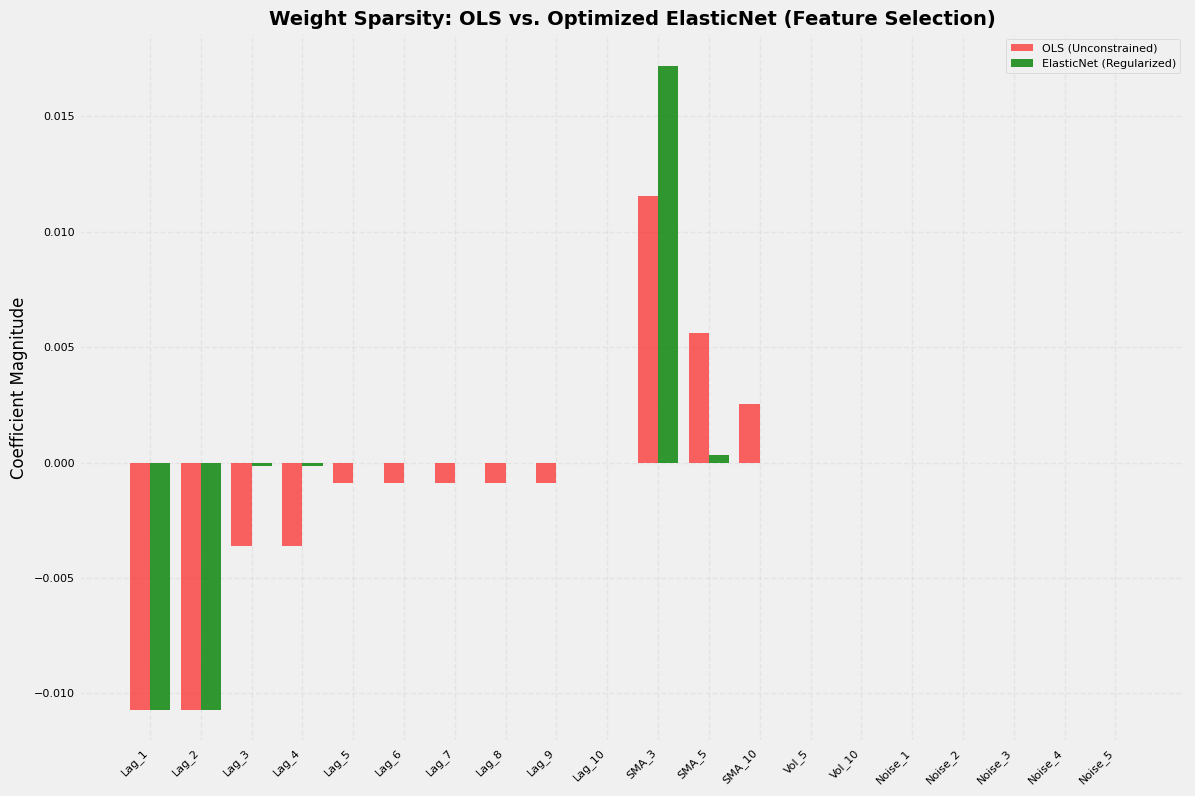

In [6]:
# ---------------------------------------------------------
# Step 5: Deconstructing Coefficient Sparsity
# ---------------------------------------------------------
print("\n--- Programmatic Coefficient Comparison ---")
coef_comparison = pd.DataFrame({
  'Feature': feature_cols,
  'OLS_Weight': ols_model.coef_,
  'ElasticNet_Weight': best_elastic.coef_
})

print(coef_comparison.to_string(index=False))

# Count non-zero elements
ols_non_zeros = np.sum(ols_model.coef_ != 0)
elastic_non_zeros = np.sum(best_elastic.coef_ != 0)

print(f"\nOLS retained {ols_non_zeros} / {len(feature_cols)} features.")
print(f"Optimized ElasticNet driven to select {elastic_non_zeros} / {len(feature_cols)} active features.")

# Plotting the weights
plt.figure(figsize=(12, 8))
x_axis = np.arange(len(feature_cols))

plt.bar(x_axis - 0.2, ols_model.coef_, width=0.4, label='OLS (Unconstrained)', color='red', alpha=0.6)
plt.bar(x_axis + 0.2, best_elastic.coef_, width=0.4, label='ElasticNet (Regularized)', color='green', alpha=0.8)

plt.xticks(x_axis, feature_cols, rotation=45, ha='right')
plt.title('Weight Sparsity: OLS vs. Optimized ElasticNet (Feature Selection)', fontsize=14, fontweight='bold')
plt.ylabel('Coefficient Magnitude', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()